# Exercises: week 10

# Exercise 1

A person is typing text, and the number of typing errors per page follows a Poisson distribution with unknown average number of errors per page.

A function `get_errors(n)` returns a list containing a number of typing errors on each of $n$ independently written pages.

1. Write a function `estimate_lambda(data)` that takes a list of observations (numbers of errors per page) and estimates the lambda parameter of the Poisson distribution.
2. Use the function `get_errors(n)` to obtain data for $n$ pages, and then use this data to estimate $\lambda$ parameter.
3. What is the estimator here, what is the estimate?
4. Run the estimator 100 times of different samples of size 100. Store all estimates in a list and plot a histogram: where is it centered? Is the estimator biased? What does the histogram width tell about the estimates?
5. Inspect the function `get_errors()` to check how close the estimate was to the true parameter.

5.01
4.9892


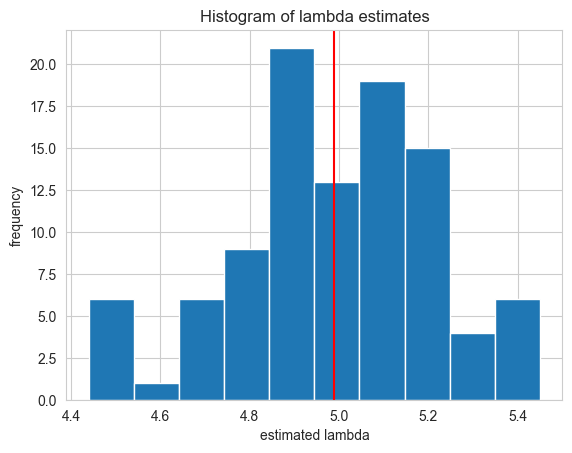

def get_errors(n: int) -> np.ndarray:
    true_lambda = 5
    return np.random.poisson(true_lambda, size=n)



In [61]:
from util_week_10 import get_errors
import numpy as np
import matplotlib.pyplot as plt

def estimate_lambda(data: np.ndarray) -> float:
    return float(np.mean(data))

def make_histogram():
  estimates = []
  for _ in range(100):
      sample = get_errors(100)
      estimates.append(estimate_lambda(sample))

  print(np.mean(estimates))

  plt.hist(estimates)
  plt.axvline(np.mean(estimates), color='red')
  plt.title("Histogram of lambda estimates")
  plt.xlabel("estimated lambda")
  plt.ylabel('frequency')
  plt.show()

n = 100
data = get_errors(n)
lambda_hat = estimate_lambda(data)
print(lambda_hat)

# estimator: the sample mean = function estimate_lambda
# estimate: the value of lambda_hat

make_histogram()

import inspect
print(inspect.getsource(get_errors))

## Exercise 2

A physicist repeatedly measures the voltage output from a device. Due to small random measurement errors, the recorded voltages vary slightly. The measured value could be modeled using a normal distribution, where the mean is the true voltage, and the variance of the normal distribution is the measurement variance. Function `get_measurements(n)` returns $n$ independent voltage measurements.

1. Write two functions that will estimate the mean and variance based on the observed measurements.
2. Generate a sample of $n$ measurements and compute mean and variance. What is the estimator, and the estimate here?
3. Repeat the estimation process on multiple data samples. Plot two histograms: one for mean and one for variance.
4. Is any estimator here biased? How does increasing sample size change the histograms?
5. Compare the results to the true values in `get_measurements()` function.

5.241866189214741
3.634121286884913
3.670829582712033


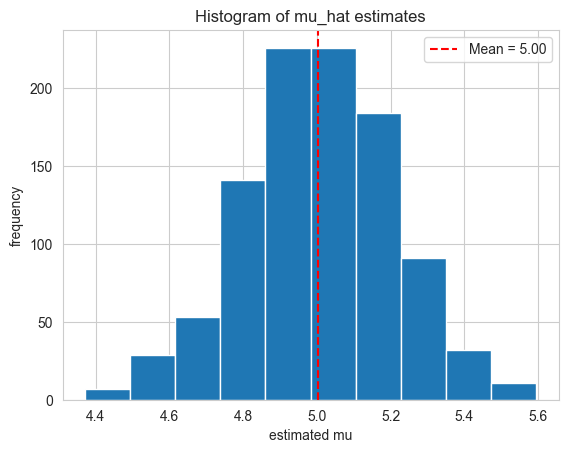

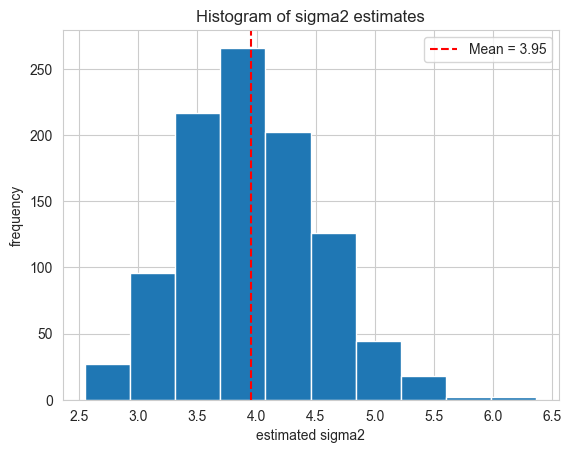

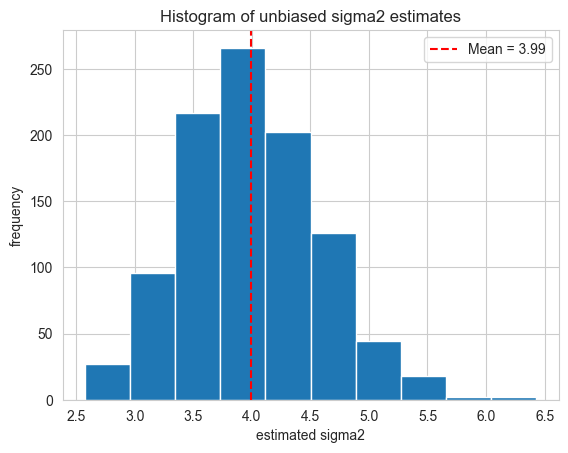

def get_measurements(n: int) -> np.ndarray:
    true_mu = 5.0
    true_sigma = 2.0
    return np.random.normal(true_mu, true_sigma, size=n)



In [62]:
from util_week_10 import get_measurements
import numpy as np
import matplotlib.pyplot as plt

def estimate_mu(data: np.ndarray):
    return np.mean(data)

def estimate_sigma2_mle(data: np.ndarray):
    mu_hat = np.mean(data)
    return np.mean((data - mu_hat)**2)

def estimate_sigma2_unbiased(data: np.ndarray):
    mu_hat = np.mean(data)
    return (np.sum((data - mu_hat)**2)) / (data.shape[0] - 1)

def plot_histogram(data, title: str, xlabel: str, ylabel: str = 'frequency'):
    plt.hist(data)
    plt.axvline(np.mean(data), color='red', linestyle='dashed', label=f'Mean = {np.mean(data):.2f}')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()

def plot_many_repetitions(n: int = 100, repetitions: int = 1000):
    mu_estimates = []
    sigma2_estimates = []
    sigma2_unbiased_estimates = []

    for _ in range(repetitions):
        sample = get_measurements(n)
        mu_estimates.append(estimate_mu(sample))
        sigma2_estimates.append(estimate_sigma2_mle(sample))
        sigma2_unbiased_estimates.append(estimate_sigma2_unbiased(sample))

    plot_histogram(mu_estimates, 'Histogram of mu_hat estimates', 'estimated mu')
    plot_histogram(sigma2_estimates, 'Histogram of sigma2 estimates', 'estimated sigma2')
    plot_histogram(sigma2_unbiased_estimates, 'Histogram of unbiased sigma2 estimates', 'estimated sigma2')

n = 100
data = get_measurements(n)

mu_hat = estimate_mu(data)
print(mu_hat)
sigma2_hat = estimate_sigma2_mle(data)
print(sigma2_hat)
unbiased_sigma2_hat = estimate_sigma2_unbiased(data)
print(unbiased_sigma2_hat)

plot_many_repetitions()

import inspect
print(inspect.getsource(get_measurements))

## Exercise 3

Alice is modeling the number of customer support tickets that a company received per hour and believes that the tickets follow a Poisson distribution with unknown rate $\lambda$. The maximum likelihood estimate for $\lambda$ in a Poisson distribution is the sample mean.

1. Write a function `generate_tickets(n, true_lambda)` that returns $n$ observations from the Poisson distribution with given `true_lambda`.
2. Write a function to compute the estimate of $\lambda$.
3. Compute the estimate of $\lambda$ for sample sizes between 1 and 100 and plot the estimate of $\lambda$ as a function of n - what happens to the estimate as n grows?
4. Write a function to repeat the computation from 3 multiple times and plot the estimates together - what do you see?

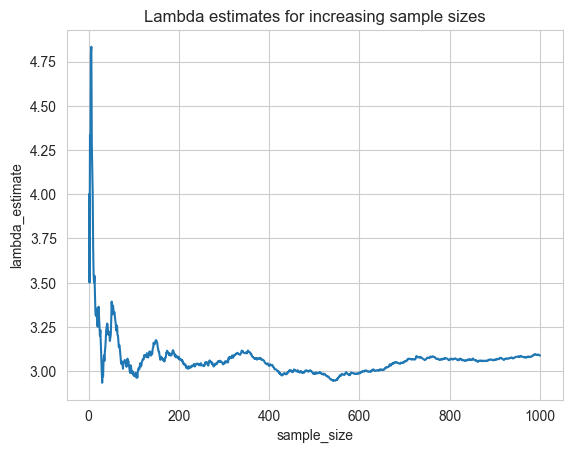

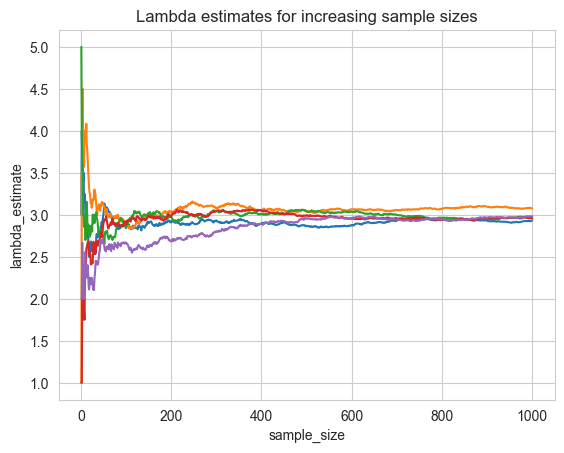

In [63]:
def generate_tickets(n: int, true_lambda: int = 3):
    return np.random.poisson(lam=true_lambda, size=n)

def estimate_lambda(data: np.ndarray):
    return np.mean(data)

def compute_estimates_for_range(sample_size_min: int = 1, sample_size_max: int = 100):

    data = generate_tickets(sample_size_max)
    lambda_estimates = [estimate_lambda(data[: i]) for i in range(sample_size_min, sample_size_max + 1)]

    # alternative: compute it on different data samples respecting the size:
    # lambda_estimates = []
    # for n in range(sample_size_min, sample_size_max + 1):
    #     data = generate_tickets(n)
    #     lambda_hat = estimate_lambda(data)
    #     lambda_estimates.append(lambda_hat)

    return lambda_estimates

def repeat_estimates_computation(sample_size_min: int = 1, sample_size_max: int = 1000, repetitions: int = 10):
    for _ in range(repetitions):
      lambda_estimates = compute_estimates_for_range(sample_size_min, sample_size_max)
      plt.plot(list(range(sample_size_min, sample_size_max + 1)), lambda_estimates)

    plt.title('Lambda estimates for increasing sample sizes')
    plt.xlabel('sample_size')
    plt.ylabel('lambda_estimate')
    plt.show()

lambda_estimates = compute_estimates_for_range(1, 1000)
plt.plot(list(range(1, 1001)), lambda_estimates) # it converges to true lambda
plt.title('Lambda estimates for increasing sample sizes')
plt.xlabel('sample_size')
plt.ylabel('lambda_estimate')
plt.show()

repeat_estimates_computation(1, 1000, 5) # they all converge to the same (true) value

## Exercise 4

Alice is analyzing the results of a series of independent coin tosses and believes the outcome follows a Bernoulli distribution with unknown probability $p$ of getting a head. She wants to estimate $p$ form data using maxiumum likelihood estimation, but her colleague suggests using another estimator here called smoothed estimator, where $\hat{p}=\frac{k+1}{n+2}$, which pretends there was one extra head and one extra tail observed in the experiment. $k$ is the number of heads and $n$ is the number of tosses.

1. Write a function `generate_coin_tosses(n, true_p)` that returns $n$ observations from the Bernoulli distribution with probability of head `true_p`.
2. Write two functions to estimate $p$: `estimate_with_mle(data)` and `estimate_with_smoothing(data)` as described above.
3. Fix `true_p` to be 0.4. Compute both estimates for sample sizes between 1 and 200 and plot them together as a function of the sample size. What happens as the sample size increases?
4. Compute the mean squared error and bias of both estimators across repeated runs and plot them as a function of the sample size. Which estimator is better? Try when `true_p` is 0.4 and 0.85. What do you observe?

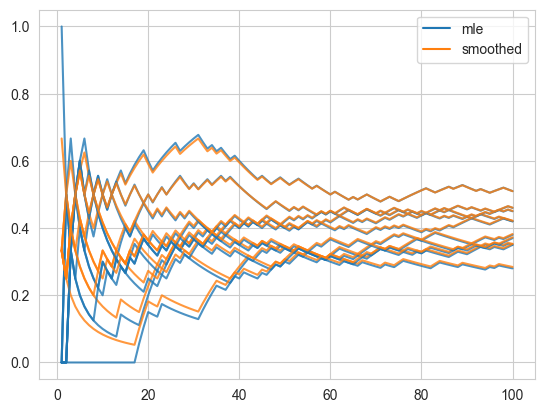

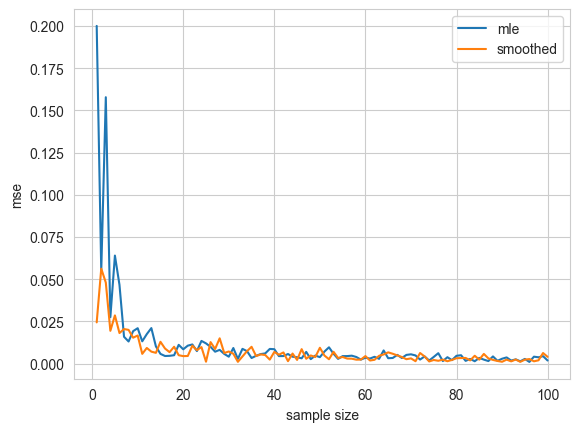

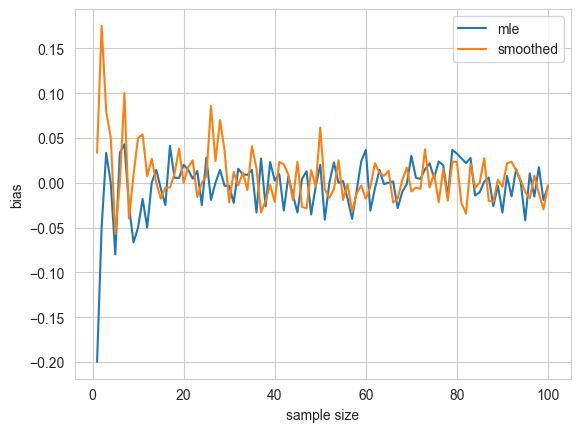

In [64]:
import numpy as np
import matplotlib.pyplot as plt

def generate_coin_tosses(n: int, true_p: float = 0.85):
    return np.random.binomial(1, true_p, size=n)

def estimate_with_mle(data: np.ndarray) -> float:
    return float(np.mean(data))

def estimate_with_smoothing(data: np.ndarray) -> float:
    return (np.sum(data) + 1) / (data.shape[0] + 2)

def repeat_estimates_computation(sample_size_min: int = 1, sample_size_max: int = 200, true_p: float = 0.85, repetitions: int = 10):
    sample_sizes = list(range(sample_size_min, sample_size_max+1))
    for _ in range(repetitions):
        data = generate_coin_tosses(sample_size_max, true_p)
        mle_estimates = [estimate_with_mle(data[:i]) for i in range(sample_size_min, sample_size_max + 1)]
        smoothed_estimates = [estimate_with_smoothing(data[:i]) for i in range(sample_size_min, sample_size_max + 1)]
        plt.plot(sample_sizes, mle_estimates, color='C0', alpha=0.8)
        plt.plot(sample_sizes, smoothed_estimates, color='C1', alpha=0.8)
    plt.plot([], [], color='C0', label='mle')
    plt.plot([], [], color='C1', label='smoothed')
    plt.legend()
    plt.show()

def mse(estimates, true_val):
    return np.mean([(estimate - true_val) ** 2 for estimate in estimates])

def bias(estimates, true_val):
    return np.mean([estimate - true_val for estimate in estimates])

def compute_mse_and_bias_per_sample_size(sample_size_min: int = 10, sample_size_max: int = 200, true_p: float = 0.85, repetitions: int = 10):
    mle_mse, mle_bias = [], []
    smoothed_mse, smoothed_bias = [], []

    for sample_size in range(sample_size_min, sample_size_max + 1):

        mle_estimates = [estimate_with_mle(generate_coin_tosses(sample_size, true_p)) for _ in range(repetitions)]
        smoothed_estimates = [estimate_with_smoothing(generate_coin_tosses(sample_size, true_p)) for _ in range(repetitions)]

        mle_mse.append(mse(mle_estimates, true_p))
        smoothed_mse.append(mse(smoothed_estimates, true_p))
        mle_bias.append(bias(mle_estimates, true_p))
        smoothed_bias.append(bias(smoothed_estimates, true_p))

    return mle_mse, smoothed_mse, mle_bias, smoothed_bias

def plot_across_sample_sizes(mle_mse, smoothed_mse, sample_sizes: list, ylabel: str):
    plt.plot(sample_sizes, mle_mse, label='mle')
    plt.plot(sample_sizes, smoothed_mse, label='smoothed')
    plt.xlabel('sample size')
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()


true_p = 0.4
repeat_estimates_computation(1, 100, true_p=true_p)
mle_mse, smoothed_mse, mle_bias, smoothed_bias = compute_mse_and_bias_per_sample_size(1, 100, true_p=true_p)
plot_across_sample_sizes(mle_mse, smoothed_mse, list(range(1, 101)), 'mse') # depending on the value of true_p, one or the other estimator may perform better (mse/bias) for smaller samples, however, they eventually converge to the same values for increasing sample sizes
plot_across_sample_sizes(mle_bias, smoothed_bias, list(range(1, 101)), 'bias')